In [1]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from pathlib import Path

In [2]:
input_path=Path().resolve()/'input'

# Loading Dataa

In [36]:
training_data=pl.read_csv(input_path/'Corona_NLP_train.csv')

# Data Preprocessing

In [37]:
training_data.null_count()

UserName,ScreenName,Location,TweetAt,OriginalTweet,Sentiment
u32,u32,u32,u32,u32,u32
0,0,8590,0,0,0


null exists at location

We will impute those nulls with unknown value

In [38]:
training_data=training_data.with_columns(pl.col('Location').fill_null('unknown'))
training_data.null_count()

UserName,ScreenName,Location,TweetAt,OriginalTweet,Sentiment
u32,u32,u32,u32,u32,u32
0,0,0,0,0,0


In [57]:
# Converting the tweetat to polars datetime
training_data=training_data.with_columns(pl.col('TweetAt').st)

InvalidOperationError: conversion from `str` to `datetime[μs]` failed in column 'TweetAt' for 159 out of 159 values: ["23-03-2020", "23-03-2020", … "23-03-2020"]

You might want to try:
- setting `strict=False` to set values that cannot be converted to `null`
- using `str.strptime`, `str.to_date`, or `str.to_datetime` and providing a format string

# Data Exploration

In [4]:
training_data.head(10)

UserName,ScreenName,Location,TweetAt,OriginalTweet,Sentiment
i64,i64,str,str,str,str
3799,48751,"""London""","""16-03-2020""","""@MeNyrbie @Phil_Gahan @Chrisit…","""Neutral"""
3800,48752,"""UK""","""16-03-2020""","""advice Talk to your neighbours…","""Positive"""
3801,48753,"""Vagabonds""","""16-03-2020""","""Coronavirus Australia: Woolwor…","""Positive"""
3802,48754,null,"""16-03-2020""","""My food stock is not the only …","""Positive"""
3803,48755,null,"""16-03-2020""","""Me, ready to go at supermarket…","""Extremely Negative"""
3804,48756,"""ÃœT: 36.319708,-82.363649""","""16-03-2020""","""As news of the regionÂ’s first…","""Positive"""
3805,48757,"""35.926541,-78.753267""","""16-03-2020""","""Cashier at grocery store was s…","""Positive"""
3806,48758,"""Austria""","""16-03-2020""","""Was at the supermarket today. …","""Neutral"""
3807,48759,"""Atlanta, GA USA""","""16-03-2020""","""Due to COVID-19 our retail sto…","""Positive"""


In [15]:
training_data.describe()

statistic,UserName,ScreenName,Location,TweetAt,OriginalTweet,Sentiment
str,f64,f64,str,str,str,str
"""count""",41157.0,41157.0,"""32567""","""41157""","""41157""","""41157"""
"""null_count""",0.0,0.0,"""8590""","""0""","""0""","""0"""
"""mean""",24377.0,69329.0,null,null,null,null
"""std""",11881.146851,11881.146851,null,null,null,null
"""min""",3799.0,48751.0,""" ""","""1/4/2020""",""" Coronavirus lingers in a…","""Extremely Negative"""
"""25%""",14088.0,59040.0,null,null,null,null
"""50%""",24377.0,69329.0,null,null,null,null
"""75%""",34666.0,79618.0,null,null,null,null
"""max""",44955.0,89907.0,"""Ã…bo, Finland""","""9/4/2020""","""Ã‡a se peut? Why Does Covid-1…","""Positive"""


There are many null values in the location field <br>
Date format for the TweetAt is not accurate needs to be changed

In [20]:
## understanding screen name
training_data.select(pl.col('ScreenName')).unique().count()

ScreenName
u32
41157


In [ ]:
# All values are unique so its an identity to the test

In [22]:
# describing the categorical variables
training_data.to_pandas().describe(include="object")

,Location,TweetAt,OriginalTweet,Sentiment
count,32567,41157,41157,41157
unique,12220,30,41157,5
top,London,20-03-2020,@MeNyrbie @Phil_Gahan @Chrisitv https://t.co/i...,Positive
freq,540,3448,1,11422


- Most common location is Londan 
- Most common tweet date is 3448
- Most common Sentiment is Positive

In [23]:
# Visualizing the sentiment column


In [20]:
from lib import loadProfile
sentiment_data=training_data.group_by('Sentiment').len().select(pl.col('Sentiment'), pl.col('len').alias('Counts'))

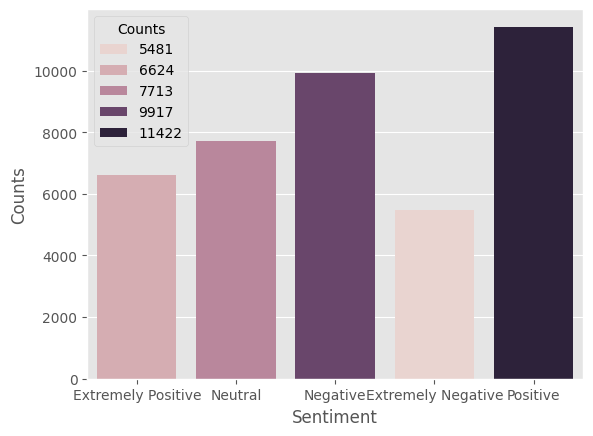

In [21]:
Plots=loadProfile(sentiment_data)
Plots.barplot_seaborn('Sentiment','Counts')

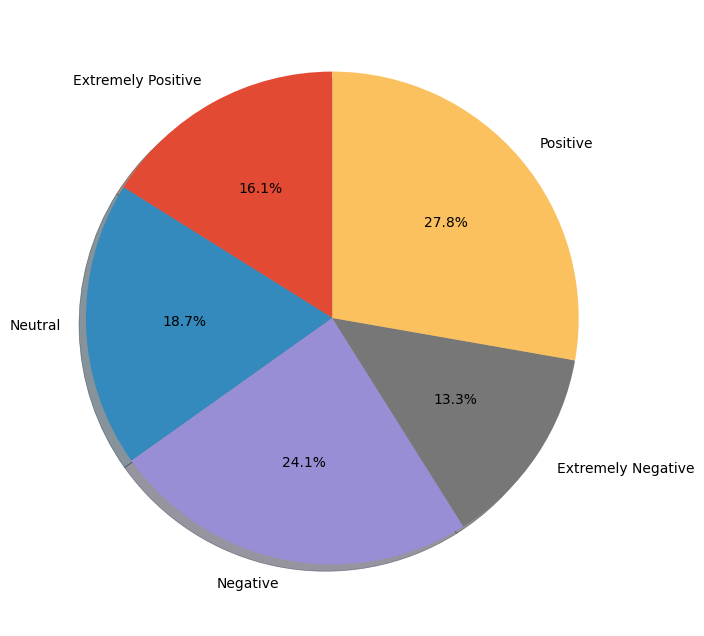

In [26]:
Plots.pie(sentiment_data,sentiment_data['Counts'],sentiment_data['Sentiment'])

In [51]:
# Correlation between Sentiment and Original Tweet
data_corr=training_data.select(pl.corr('OriginalTweet','Sentiment',method="spearman"))
data_corr

OriginalTweet
f64
0.000256
